# [varseek X chromosome example](https://github.com/pachterlab/varseek) demonstration

Written by Joseph Rich.
___


In [1]:
try:
    import varseek as vk
except ImportError:
    print("varseek not found, installing...")
    !pip install -U -q varseek

In [2]:
import os
import pandas as pd
from pathlib import Path
import pysam
from Bio import SeqIO
from Bio.SeqIO.QualityIO import FastqGeneralIterator
import subprocess
import anndata as ad
import scanpy as sc

import varseek as vk

### Define important paths

In [3]:
# input files
fastqs_dir = os.path.join("data", "pbmc_1k_v3_fastqs")
technology = "10xv3"
read_length = 91
reference_dir = "/home/jrich/data/reference"  # os.path.join("data", "reference")

# STAR files
star_genome_index_dir = os.path.join(reference_dir, "ensembl_grch38_release114", "star_index")
fasta_ref = os.path.join(reference_dir, "ensembl_grch38_release114", "Homo_sapiens.GRCh38.dna.primary_assembly.fa")
gtf = os.path.join(reference_dir, "ensembl_grch38_release114", "Homo_sapiens.GRCh38.114.gtf")
star_prefix = "data/pbmc_1k_v3_star/star_"

# vk ref out
vk_ref_out_dir = os.path.join("data", "varseek_ref_out_pbmc_1k_v3_x_chrom")
vcrs_index = os.path.join(vk_ref_out_dir, "vcrs_index_x_chrom.idx")
vcrs_t2g = os.path.join(vk_ref_out_dir, "vcrs_t2g_x_chrom.txt")

# vk count out
vk_count_out_dir = os.path.join("data", "varseek_count_out_pbmc_1k_v3_x_chrom")

# general parameters
w = 37
k = 41
threads = 16

In [4]:
fastq_r2_files = sorted(
    os.path.join(root, file)
    for root, _, files in os.walk(fastqs_dir)
    for file in files
    if file.endswith((".fastq.gz", ".fq.gz", ".fastq", ".fq")) and "_R2_" in file
)

## Map to reference

In [5]:
read_length_minus_one = read_length - 1

if not os.path.exists(star_genome_index_dir):
    star_build_command = f"STAR --runMode genomeGenerate \
        --runThreadN {threads} \
        --genomeDir {star_genome_index_dir} \
        --genomeFastaFiles {fasta_ref} \
        --sjdbGTFfile {gtf} \
        --sjdbOverhang {read_length_minus_one} \
        --limitSjdbInsertNsj 1000000 \
        --limitBAMsortRAM 0"
    subprocess.run(star_build_command, shell=True, check=True)

inputs_star = ",".join(fastq_r2_files)
if not os.path.exists(star_prefix + "Aligned.sortedByCoord.out.bam"):
    star_run_cmd = f"STAR \
        --runThreadN {threads} \
        --genomeDir {star_genome_index_dir} \
        --readFilesIn {inputs_star} \
        --sjdbOverhang {read_length_minus_one} \
        --outFileNamePrefix {star_prefix} \
        --outSAMtype BAM SortedByCoordinate \
        --outSAMmapqUnique 60 \
        --twopassMode Basic \
        --limitSjdbInsertNsj 1000000 \
        --limitBAMsortRAM 0"
    if fastq_r2_files[0].endswith(".gz"):
        star_run_cmd += " --readFilesCommand zcat"
    subprocess.run(star_run_cmd, shell=True, check=True)

## Only keep X chromosome reads

In [6]:
# --------------------------------------------------
# Paths
# --------------------------------------------------

bam_path = Path(f"{star_prefix}Aligned.sortedByCoord.out.bam")
fastq_dir = Path(fastqs_dir)
fastq_dir_x_chrom = Path(fastqs_dir.replace("pbmc_1k_v3_fastqs", "pbmc_1k_v3_fastqs_x_chrom"))

fastq_dir_x_chrom.mkdir(parents=True, exist_ok=True)

if not os.path.exists(f"{bam_path}.bai"):
    !samtools index {bam_path}

# --------------------------------------------------
# Step 1:
# Collect read IDs mapping to chromosome X
# --------------------------------------------------

x_read_ids = set()

with pysam.AlignmentFile(bam_path, "rb") as bam:

    for read in bam.fetch("X"):

        # skip unmapped / secondary / supplementary
        if (
            read.is_unmapped
            or read.is_secondary
            or read.is_supplementary
        ):
            continue

        x_read_ids.add(read.query_name)

print(f"Found {len(x_read_ids):,} read IDs mapping to chrX")

# --------------------------------------------------
# Step 2:
# Identify FASTQ files
# --------------------------------------------------

fastq_files = sorted(fastq_dir.glob("*.fastq*"))

print("FASTQ files:")
for f in fastq_files:
    print("  ", f.name)

# --------------------------------------------------
# Step 3:
# Filter FASTQs
# --------------------------------------------------

for input_fastq in fastq_files:

    output_fastq = fastq_dir_x_chrom / input_fastq.name
    if not output_fastq.exists():

        print(f"\nFiltering {input_fastq.name}")

        # auto-handle gzipped vs plain
        if input_fastq.suffix == ".gz":
            import gzip
            fin = gzip.open(input_fastq, "rt")
            fout = gzip.open(output_fastq, "wt")
        else:
            fin = open(input_fastq, "r")
            fout = open(output_fastq, "w")

        kept = 0
        total = 0

        with fin, fout:

            for title, seq, qual in FastqGeneralIterator(fin):

                total += 1

                # read name before any whitespace
                read_id = title.split()[0]

                # remove /1 or /2 if present
                read_id = read_id.replace("/1", "").replace("/2", "")

                if read_id in x_read_ids:

                    fout.write(f"@{title}\n{seq}\n+\n{qual}\n")
                    kept += 1

        print(f"Kept {kept:,} / {total:,} reads")

print("\nDone.")
print(f"Filtered FASTQs written to:\n{fastq_dir_x_chrom}")

Found 2,034,200 read IDs mapping to chrX
FASTQ files:
   pbmc_1k_v3_S1_L001_I1_001.fastq.gz
   pbmc_1k_v3_S1_L001_R1_001.fastq.gz
   pbmc_1k_v3_S1_L001_R2_001.fastq.gz
   pbmc_1k_v3_S1_L002_I1_001.fastq.gz
   pbmc_1k_v3_S1_L002_R1_001.fastq.gz
   pbmc_1k_v3_S1_L002_R2_001.fastq.gz

Done.
Filtered FASTQs written to:
data/pbmc_1k_v3_fastqs_x_chrom


In [7]:
fastq_r2_files_x_chrom = sorted(
    os.path.join(root, file)
    for root, _, files in os.walk(fastq_dir_x_chrom)
    for file in files
    if file.endswith((".fastq.gz", ".fq.gz", ".fastq", ".fq")) and "_R2_" in file
)

fastq_r1_and_r2_files_x_chrom = sorted(
    os.path.join(root, file)
    for root, _, files in os.walk(fastq_dir_x_chrom)
    for file in files
    if file.endswith((".fastq.gz", ".fq.gz", ".fastq", ".fq")) and ("_R1_" in file or "_R2_" in file)
)

## Make varseek reference

In [8]:
from pathlib import Path
import os
import gzip
from tqdm import tqdm
from Bio.SeqIO.QualityIO import FastqGeneralIterator

output_fasta = Path(f"{vk_ref_out_dir}/vcrs.fa")
vcrs_t2g = Path(vcrs_t2g)

seen = set()

BUFFER_SIZE = 10000

if not output_fasta.exists() or not vcrs_t2g.exists():

    output_fasta.parent.mkdir(parents=True, exist_ok=True)
    vcrs_t2g.parent.mkdir(parents=True, exist_ok=True)

    fa_buffer = []
    t2g_buffer = []

    n_written = 0

    with open(output_fasta, "w") as fout_fa, open(vcrs_t2g, "w") as fout_t2g:

        # t2g header
        fout_t2g.write("transcript_id\tgene_id\n")

        for fastq_file in tqdm(
            fastq_r2_files_x_chrom,
            desc="FASTQ files"
        ):

            print("Processing:", fastq_file)

            with gzip.open(fastq_file, "rt") as fin:

                for title, seq, qual in tqdm(
                    FastqGeneralIterator(fin),
                    desc=Path(fastq_file).name,
                    leave=False,
                ):

                    seq = seq.upper()

                    if len(seq) < k:
                        continue

                    for i in range(len(seq) - k + 1):

                        kmer = seq[i:i+k]

                        # skip ambiguous kmers
                        if "N" in kmer:
                            continue

                        # deduplicate
                        if kmer in seen:
                            continue

                        seen.add(kmer)

                        # add to buffers
                        fa_buffer.append(f">{kmer}\n{kmer}\n")
                        t2g_buffer.append(f"{kmer}\t{kmer}\n")

                        n_written += 1

                        # flush periodically
                        if len(fa_buffer) >= BUFFER_SIZE:

                            fout_fa.writelines(fa_buffer)
                            fout_t2g.writelines(t2g_buffer)

                            fa_buffer.clear()
                            t2g_buffer.clear()

        # final flush
        if fa_buffer:
            fout_fa.writelines(fa_buffer)
            fout_t2g.writelines(t2g_buffer)

        fout_fa.flush()
        fout_t2g.flush()

        os.fsync(fout_fa.fileno())
        os.fsync(fout_t2g.fileno())

    print(f"Wrote {n_written:,} unique kmers")

if not os.path.exists(vcrs_index):

    !kb ref \
        --workflow custom \
        -t {threads} \
        -k {k} \
        -i {vcrs_index} \
        {output_fasta}

## Run varseek count

In [9]:
fastq_r2_files_x_chrom_str = " ".join(fastq_r2_files_x_chrom)

if not os.path.exists(vk_count_out_dir):
    !kb count \
        -i {vcrs_index} \
        -g {vcrs_t2g} \
        -x {technology} \
        -o {vk_count_out_dir} \
        --union \
        --mm \
        -k {k} \
        -t {threads} \
        --h5ad \
        {fastq_r2_files_x_chrom_str}    

[2026-05-19 08:43:35,586]    INFO [count] Using index data/varseek_ref_out_pbmc_1k_v3_x_chrom/vcrs_index_x_chrom.idx to generate BUS file to data/varseek_count_out_pbmc_1k_v3_x_chrom from
[2026-05-19 08:43:35,586]    INFO [count]         data/pbmc_1k_v3_fastqs_x_chrom/pbmc_1k_v3_S1_L001_R2_001.fastq.gz
[2026-05-19 08:43:35,586]    INFO [count]         data/pbmc_1k_v3_fastqs_x_chrom/pbmc_1k_v3_S1_L002_R2_001.fastq.gz
[2026-05-19 08:44:37,707]    INFO [count] Sorting BUS file data/varseek_count_out_pbmc_1k_v3_x_chrom/output.bus to data/varseek_count_out_pbmc_1k_v3_x_chrom/tmp/output.s.bus
[2026-05-19 08:44:40,514]    INFO [count] On-list not provided
[2026-05-19 08:44:40,514]    INFO [count] Copying pre-packaged 10XV3 on-list to data/varseek_count_out_pbmc_1k_v3_x_chrom
[2026-05-19 08:44:41,334]    INFO [count] Inspecting BUS file data/varseek_count_out_pbmc_1k_v3_x_chrom/tmp/output.s.bus
[2026-05-19 08:44:47,950]    INFO [count] Correcting BUS records in data/varseek_count_out_pbmc_1k_v

In [10]:
adata = ad.read_h5ad(f"{vk_count_out_dir}/counts_unfiltered/adata.h5ad")
adata

AnnData object with n_obs × n_vars = 3862 × 14509529

In [11]:
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.filter_cells(adata, min_genes=3)
adata

AnnData object with n_obs × n_vars = 2742 × 17587
    obs: 'n_genes'
    var: 'n_cells'

In [12]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)
sc.pp.scale(adata, max_value=10)
sc.pp.pca(adata, n_comps=50)

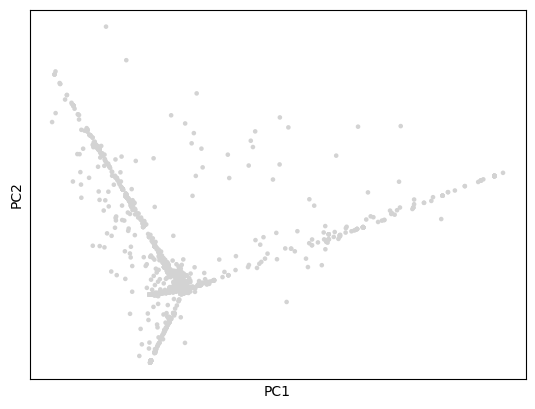

In [13]:
sc.pl.pca(adata)

In [14]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=50)
sc.tl.leiden(adata, resolution=0.01)

/home/jrich/miniconda3/envs/varseek/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/home/jrich/tmp/ipykernel_2380871/1750513837.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.01)


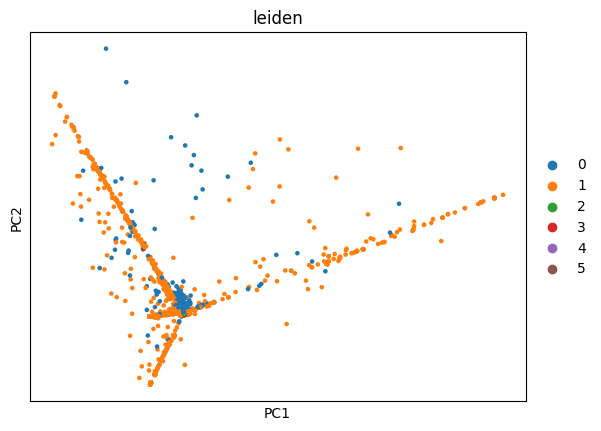

In [15]:
sc.pl.pca(adata, color="leiden")